# Ôn metric và xem detector một frame

Chạy notebook bằng kernel **cv_robotics_lab21** trong môi trường `.venv`. Mở Jupyter từ thư mục gốc của dự án. Notebook sẽ tự tìm dữ liệu tại `data_lab21/data_lab21`; nếu bạn giải nén dữ liệu ở nơi khác, đặt `LAB_DATA` trong PowerShell **trước khi mở Jupyter**:

~~~powershell
$env:LAB_DATA = (Resolve-Path .\data_lab21\data_lab21).Path
~~~

Thay đường dẫn trên nếu thư mục dữ liệu nằm ở nơi khác. Sau khi đặt biến môi trường, mở lại Jupyter để kernel nhận biến đó.

## Ba thước đo không kể cùng một câu chuyện

Chuỗi dưới đây là ID mà tracker gán cho **một** người thật qua 10 frame. Dấu chấm nghĩa là tracker **bỏ sót** frame đó (không có hộp).

- **MOTA** phạt lỗi theo **số lần**: bỏ sót, hộp giả, và mỗi lần đổi ID. Đổi ID một lần rồi giữ sai đến hết chỉ bị trừ một lần. Đổi ID liên tục bị trừ nhiều lần.
- **IDF1** nhìn cả track dài. Gán sai danh tính rồi giữ sai đến hết làm IDF1 tụt, dù MOTA vẫn cao.
- **HOTA** cân bằng hai việc: phát hiện đúng người (Detection) và giữ đúng danh tính (Association). Hai tracker cùng kém ở phần giữ ID có thể có HOTA gần nhau dù MOTA khác xa.

Số trong bảng đã tính sẵn trên ví dụ ngắn. Bạn đọc bảng và trả lời, không cần sửa công thức.


In [1]:
bang = [
    # tracker, chuỗi ID, MOTA, IDF1, HOTA, số lần đổi ID
    ("A", "1111112222", 0.90, 0.60, 0.72, 1),
    ("B", "1212121212", 0.10, 0.50, 0.71, 9),
    ("C", "111111....", 0.60, 0.75, 0.60, 0),
    ("D", "1111111111", 1.00, 1.00, 1.00, 0),
]
print(f"{'Tracker':8} {'Chuỗi':12} {'MOTA':6} {'IDF1':6} {'HOTA':6} {'Đổi ID':6}")
for row in bang:
    ten, chuoi, mota, idf1, hota, doi_id = row
    print(f"{ten:8} {chuoi:12} {mota:6.2f} {idf1:6.2f} {hota:6.2f} {doi_id:6d}")


Tracker  Chuỗi        MOTA   IDF1   HOTA   Đổi ID
A        1111112222     0.90   0.60   0.72      1
B        1212121212     0.10   0.50   0.71      9
C        111111....     0.60   0.75   0.60      0
D        1111111111     1.00   1.00   1.00      0


Điền `True` hoặc `False`, rồi chạy ô kiểm tra.

1. MOTA phạt tracker B nặng vì B đổi ID rất nhiều lần, dù mỗi lần đổi chỉ kéo dài một frame.
2. HOTA phân biệt A và B rõ hơn IDF1.
3. Tracker C bỏ sót bốn frame cuối nhưng không đổi ID, nên IDF1 của C cao hơn A trong khi MOTA của C thấp hơn A.

In [2]:
nhan_dinh_1 = True  # MOTA phạt mạnh số lần đổi ID
nhan_dinh_2 = False  # HOTA tách A và B rõ hơn IDF1
nhan_dinh_3 = True  # C: IDF1 cao hơn A, MOTA thấp hơn A

dap_an = {1: True, 2: False, 3: True}
ban_chon = {1: nhan_dinh_1, 2: nhan_dinh_2, 3: nhan_dinh_3}
for cau, dung in dap_an.items():
    if ban_chon[cau] is None:
        print(f"Câu {cau}: chưa điền")
    elif ban_chon[cau] == dung:
        print(f"Câu {cau}: đúng")
    else:
        print(f"Câu {cau}: xem lại bảng — HOTA của A và B gần nhau, IDF1 cách xa hơn")


Câu 1: đúng
Câu 2: đúng
Câu 3: đúng


## Detector chưa phải tracker

YOLO nhìn **từng ảnh một**. Nó vẽ hộp quanh người và cho một điểm tin cậy. Nó **không** nhớ người ở frame trước, nên **không có ID**.

Tracker nhận các hộp đó rồi mới gán ID theo thời gian. Đổi `--conf` hoặc `--iou` là đổi ngưỡng của YOLO (hộp nào được giữ), không phải ngưỡng bên trong tracker.

Hai ô dưới chạy `yolo26n.pt` trên **một** ảnh của `video_1`. Cả lớp dùng chung trọng số này, kích thước ảnh 640 px, chỉ lớp người.

Thư mục dữ liệu: D:\Ai in Action\K4-Track4-Day22-Tracking-Student\data_lab21\data_lab21
Ảnh kiểm tra: 000001.jpg


conf=0.30, iou=0.50 -> 6 hộp người. YOLO chưa gán ID.


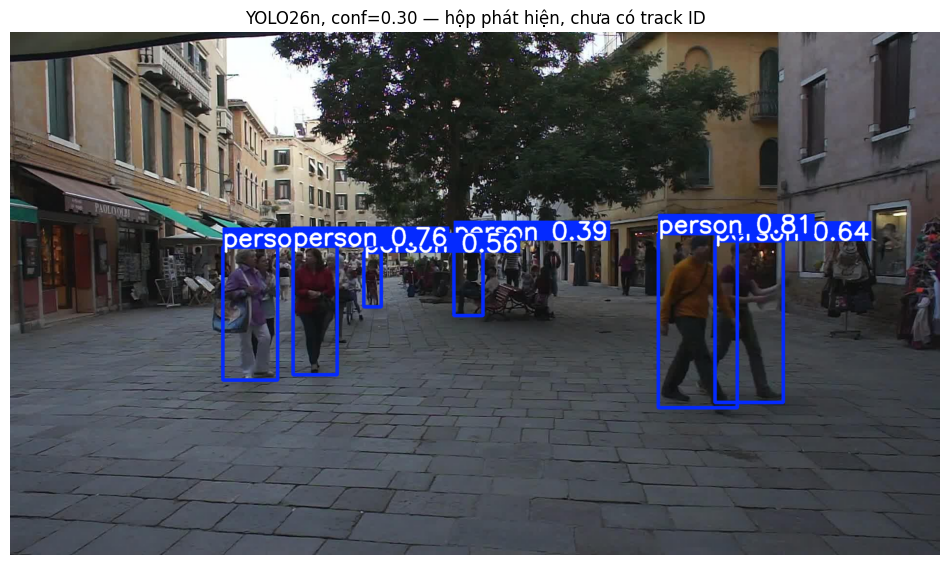

In [3]:
import os
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

IMG_SIZE = 640
PERSON_CLASS_ID = 0
DETECTOR_WEIGHTS = "yolo26n.pt"

lab_data = os.environ.get("LAB_DATA", "").strip()
if lab_data:
    lab_data_root = Path(lab_data).expanduser()
else:
    lab_data_root = Path.cwd() / "data_lab21" / "data_lab21"

image_dir = lab_data_root / "video_1" / "img1"
if not image_dir.is_dir():
    raise FileNotFoundError(
        f"Không tìm thấy thư mục ảnh {image_dir}. Mở notebook từ thư mục gốc dự án "
        "hoặc đặt LAB_DATA trước khi mở Jupyter."
    )

frames = sorted(image_dir.glob("*.jpg"))
if not frames:
    raise FileNotFoundError(f"Không có ảnh .jpg trong {image_dir}")

frame_path = frames[0]
frame_bgr = cv2.imread(str(frame_path))
if frame_bgr is None:
    raise RuntimeError(f"OpenCV không đọc được ảnh {frame_path}")

print(f"Thư mục dữ liệu: {lab_data_root.resolve()}")
print(f"Ảnh kiểm tra: {frame_path.name}")

detector = YOLO(DETECTOR_WEIGHTS)
result = detector.predict(
    frame_bgr,
    conf=0.3,
    iou=0.5,
    imgsz=IMG_SIZE,
    classes=[PERSON_CLASS_ID],
    verbose=False,
)[0]
n_boxes = 0 if result.boxes is None else len(result.boxes)
print(f"conf=0.30, iou=0.50 -> {n_boxes} hộp người. YOLO chưa gán ID.")

vis = cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB)
plt.figure(figsize=(12, 7))
plt.imshow(vis)
plt.axis("off")
plt.title("YOLO26n, conf=0.30 — hộp phát hiện, chưa có track ID")
plt.show()


In [4]:
if detector is None or frame_bgr is None:
    raise RuntimeError("Ô detector chưa chạy thành công; hãy chạy lại ô phía trên.")

for conf in (0.15, 0.5):
    result = detector.predict(
        frame_bgr,
        conf=conf,
        iou=0.5,
        imgsz=IMG_SIZE,
        classes=[PERSON_CLASS_ID],
        verbose=False,
    )[0]
    n_boxes = 0 if result.boxes is None else len(result.boxes)
    print(f"conf={conf:.2f} -> {n_boxes} hộp người")

print("Đối chiếu với conf=0.30 ở ô trên: conf thấp thường tăng số hộp, còn conf cao có thể bỏ sót người nhỏ hoặc ở vùng tối.")


conf=0.15 -> 14 hộp người
conf=0.50 -> 5 hộp người
Đối chiếu với conf=0.30 ở ô trên: conf thấp thường tăng số hộp, còn conf cao có thể bỏ sót người nhỏ hoặc ở vùng tối.


## Sang bước tracking

ID chỉ xuất hiện khi bạn chạy `scripts/run_tracking.py`. Script đó lấy hộp YOLO rồi đưa vào tracker (`bytetrack`, `ocsort`, `botsort`, `strongsort`, hoặc `deepocsort`).

Khi viết báo cáo, tách hai loại lỗi:

- Đổi ID liên tục (kiểu B) làm MOTA tụt mạnh.
- Đổi ID một lần rồi giữ sai (kiểu A) vẫn có MOTA cao. IDF1 và video lộ hậu quả rõ hơn.
- Bỏ sót người (kiểu C) khác với gán nhầm người.

Chỉ `video_1` có bảng số. Bốn video kia bạn mô tả đúng kiểu lỗi này bằng mắt.